In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv(r"C:\Users\chaur\OneDrive\Desktop\netflix-recommendation\netflix_titles.csv")
print("Shape:", df.shape)
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
print("Column names:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Column names:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [7]:
# 1. Fill missing directors with 'Unknown'
df['director'].fillna('Unknown', inplace=True)

# 2. Fill missing cast with 'Unknown'
df['cast'].fillna('Unknown', inplace=True)

# 3. Fill missing country with 'Unknown'
df['country'].fillna('Unknown', inplace=True)

# 4. Drop rows with missing rating and duration (only 4+3 rows)
df.dropna(subset=['rating', 'duration'], inplace=True)

# 5. Fill missing date_added with most frequent value
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

# 6. Strip whitespace from date_added
df['date_added'] = df['date_added'].str.strip()

# Verify no missing values remain
print("Missing values after cleaning:\n", df.isnull().sum())
print("\nNew shape:", df.shape)

Missing values after cleaning:
 show_id            0
type               0
title              0
director        2631
cast             825
country          830
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

New shape: (8800, 12)


C:\Users\chaur\AppData\Local\Temp\ipykernel_14560\661384029.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna('Unknown', inplace=True)
C:\Users\chaur\AppData\Local\Temp\ipykernel_14560\661384029.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

In [8]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract month and year added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Separate duration into value and unit
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')

print("New columns added!")
print(df[['duration', 'duration_value', 'duration_unit']].head())

New columns added!
    duration  duration_value duration_unit
0     90 min            90.0           min
1  2 Seasons             2.0       Seasons
2   1 Season             1.0        Season
3   1 Season             1.0        Season
4  2 Seasons             2.0       Seasons


In [9]:
print("Content types:\n", df['type'].value_counts())
print("\nTop countries:\n", df['country'].value_counts().head(10))
print("\nRatings:\n", df['rating'].value_counts())

Content types:
 type
Movie      6126
TV Show    2674
Name: count, dtype: int64

Top countries:
 country
United States     2815
India              972
United Kingdom     419
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Ratings:
 rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


<Figure size 800x600 with 0 Axes>

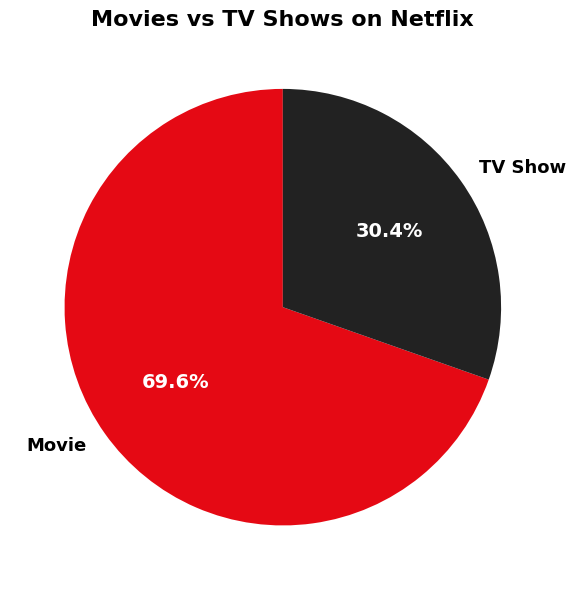

In [14]:
plt.figure(figsize=(8,6))
colors = ['#E50914', "#222222"]

wedges, texts, autotexts = df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 13}
).get_figure().gca().patches, [], []

# Better approach:
plt.clf()
fig, ax = plt.subplots(figsize=(8,6))
values = df['type'].value_counts()
wedges, texts, autotexts = ax.pie(values, 
                                   labels=values.index,
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90,
                                   textprops={'fontsize': 13})

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

# Make label text bigger
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

plt.title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/movies_vs_tvshows.png', dpi=150)
plt.show()

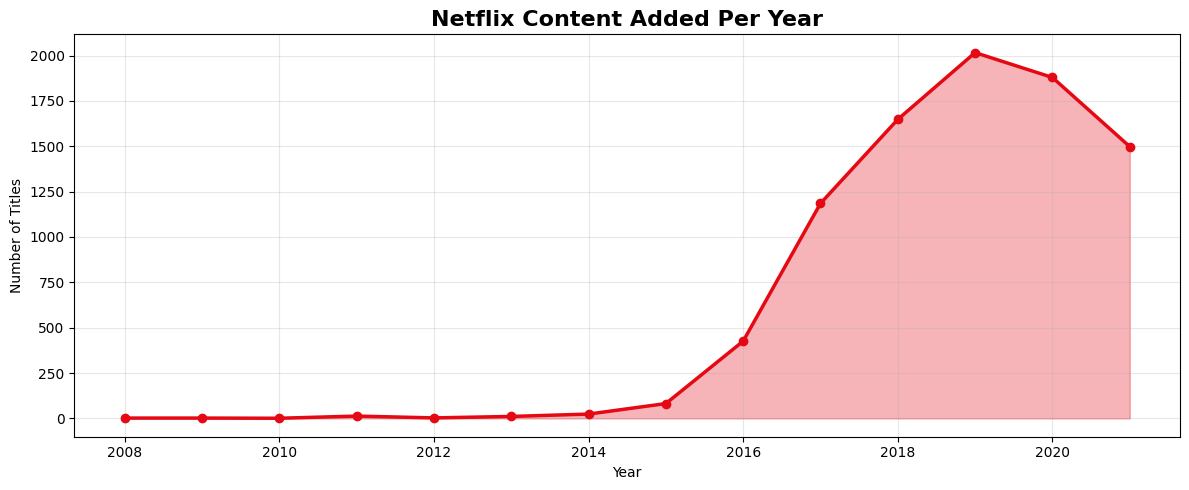

In [15]:
yearly = df.groupby('year_added')['show_id'].count().reset_index()
yearly.columns = ['Year', 'Count']

plt.figure(figsize=(12,5))
plt.plot(yearly['Year'], yearly['Count'], 
         color='#E50914', marker='o', linewidth=2.5)
plt.fill_between(yearly['Year'], yearly['Count'], alpha=0.3, color='#E50914')
plt.title('Netflix Content Added Per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/content_per_year.png', dpi=150)
plt.show()

C:\Users\chaur\AppData\Local\Temp\ipykernel_14560\587440343.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


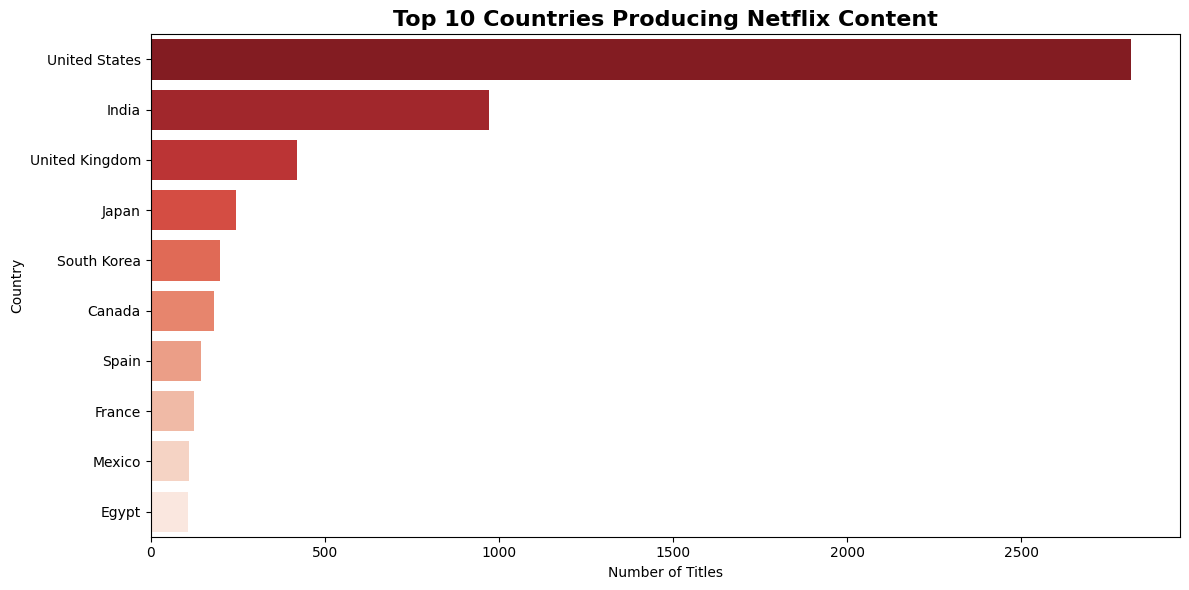

In [16]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('outputs/top_countries.png', dpi=150)
plt.show()

C:\Users\chaur\AppData\Local\Temp\ipykernel_14560\1839362398.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='Count', y='Genre', palette='Reds_r')


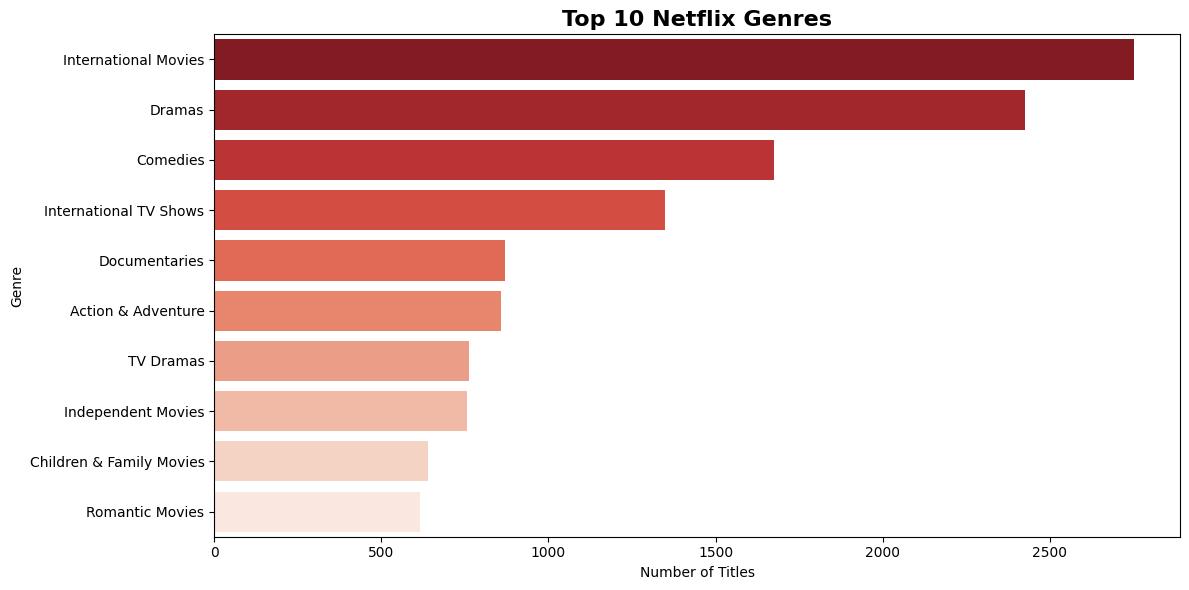

In [17]:
from collections import Counter

all_genres = []
for genres in df['listed_in']:
    all_genres.extend([g.strip() for g in genres.split(',')])

genre_counts = Counter(all_genres)
top_genres = pd.DataFrame(genre_counts.most_common(10), 
                           columns=['Genre', 'Count'])

plt.figure(figsize=(12,6))
sns.barplot(data=top_genres, x='Count', y='Genre', palette='Reds_r')
plt.title('Top 10 Netflix Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('outputs/top_genres.png', dpi=150)
plt.show()

C:\Users\chaur\AppData\Local\Temp\ipykernel_14560\1256504553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Reds_r')


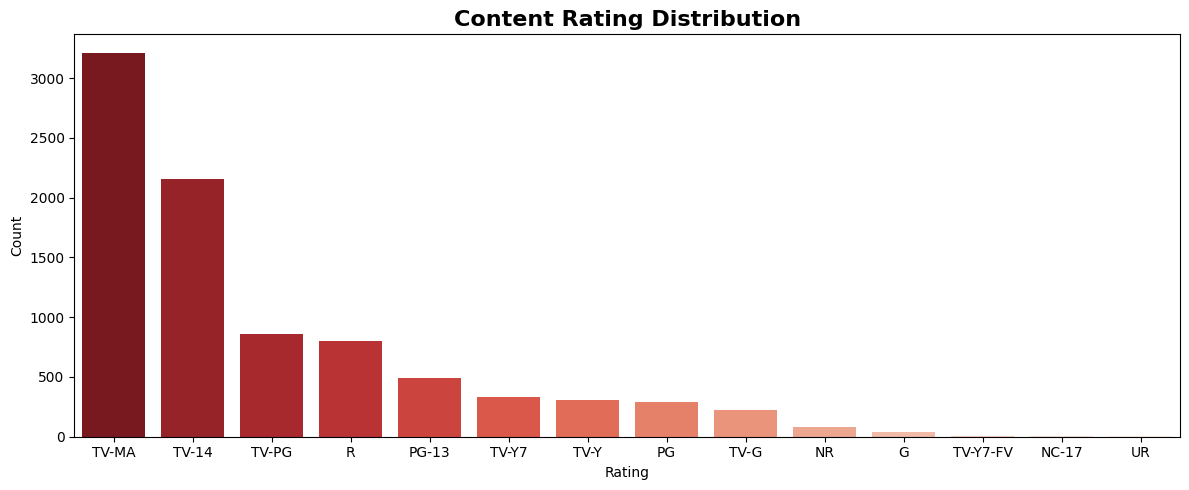

In [18]:
plt.figure(figsize=(12,5))
rating_counts = df['rating'].value_counts()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='Reds_r')
plt.title('Content Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/rating_distribution.png', dpi=150)
plt.show()

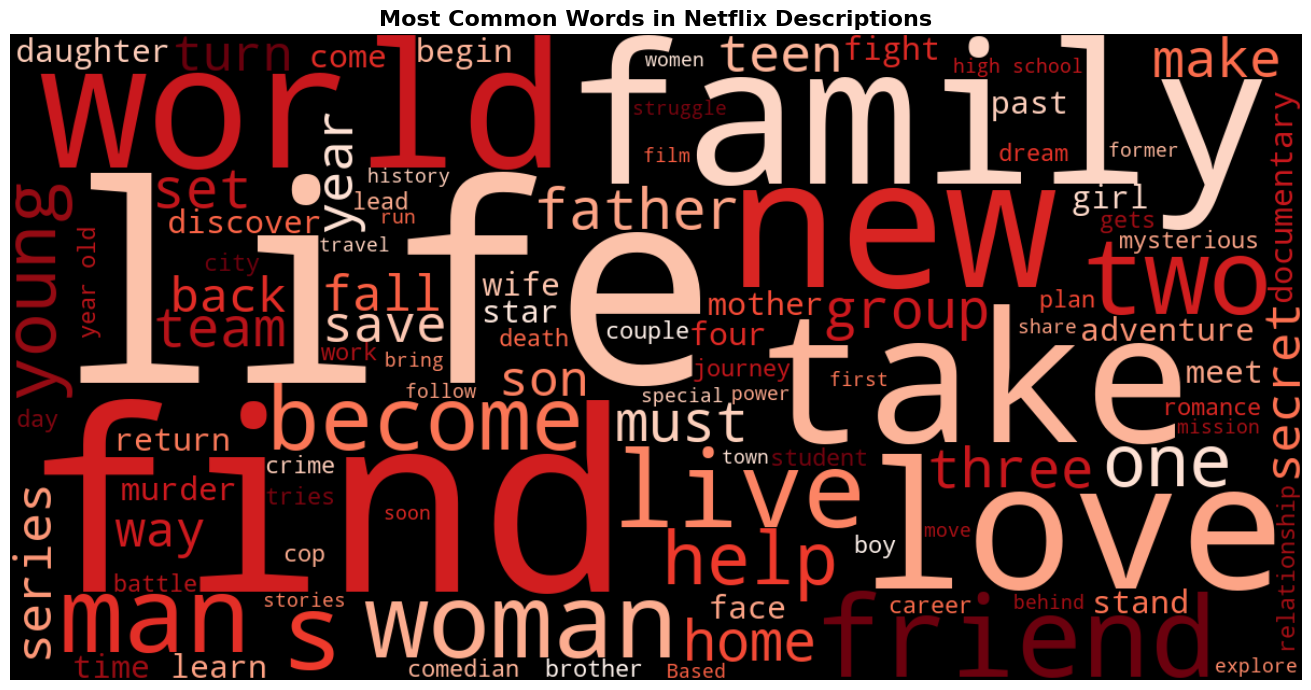

In [19]:
from wordcloud import WordCloud

text = ' '.join(df['description'].dropna())

wordcloud = WordCloud(width=1200, height=600,
                      background_color='black',
                      colormap='Reds',
                      max_words=100).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Descriptions', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/wordcloud.png', dpi=150)
plt.show()

In [27]:
# Reset and rebuild content_tags properly
df2 = df.copy()

# Fill all nulls first
df2['director'] = df2['director'].fillna('')
df2['cast'] = df2['cast'].fillna('')
df2['listed_in'] = df2['listed_in'].fillna('')
df2['description'] = df2['description'].fillna('')
df2['type'] = df2['type'].fillna('')
df2['rating'] = df2['rating'].fillna('')

# Combine columns
df2['content_tags'] = (df2['title'] + ' ' + 
                       df2['director'] + ' ' + 
                       df2['cast'] + ' ' + 
                       df2['listed_in'] + ' ' + 
                       df2['description'] + ' ' +
                       df2['type'] + ' ' +
                       df2['rating'])

# Clean
df2['content_tags'] = df2['content_tags'].str.lower().str.replace(',', ' ')

# Verify
print("Null count:", df2['content_tags'].isnull().sum())
print("\nSample tag:")
print(df2['content_tags'].iloc[0])

Null count: 0

Sample tag:
dick johnson is dead kirsten johnson  documentaries as her father nears the end of his life  filmmaker kirsten johnson stages his death in inventive and comical ways to help them both face the inevitable. movie pg-13


In [22]:
# Check for any remaining nulls in content_tags
print("Null values in content_tags:", df['content_tags'].isnull().sum())

# Fill any nulls
df['content_tags'] = df['content_tags'].fillna('')

# Verify
print("After fix:", df['content_tags'].isnull().sum())

Null values in content_tags: 3104
After fix: 0


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df2['content_tags'])

print("Matrix shape:", tfidf_matrix.shape)

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Similarity matrix shape:", cosine_sim.shape)

# Check if similarity scores look right
print("\nSample scores for row 0:", cosine_sim[0][:5])

Matrix shape: (8800, 5000)
Similarity matrix shape: (8800, 8800)

Sample scores for row 0: [1.         0.         0.         0.         0.01296741]


In [24]:
# Calculate cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine Similarity Matrix Shape:", cosine_sim.shape)
print("\nSample similarity scores:", cosine_sim[0][:5])

Cosine Similarity Matrix Shape: (8800, 8800)

Sample similarity scores: [0. 0. 0. 0. 0.]


In [29]:
df2 = df2.reset_index(drop=True)
title_to_idx = pd.Series(df2.index, index=df2['title'])

def get_recommendations(title, n=10):
    if title not in title_to_idx:
        return f"'{title}' not found!"
    
    idx = title_to_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    
    result = df2[['title', 'type', 'listed_in', 
                  'rating', 'description']].iloc[movie_indices].copy()
    result['similarity_score'] = [round(i[1], 3) for i in sim_scores]
    return result

# Test
get_recommendations('Stranger Things', n=10)

,title,type,listed_in,rating,description,similarity_score
5200,Beyond Stranger Things,TV Show,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV...",TV-14,"Secrets from the ""Stranger Things 2"" universe ...",0.553
6699,Equilibrium,Movie,"Action & Adventure, Dramas, Sci-Fi & Fantasy",R,"In a dystopian future, a totalitarian regime m...",0.196
964,Things Heard & Seen,Movie,"Horror Movies, Thrillers",TV-MA,A young woman discovers that both her husband ...,0.188
1335,The Sinner,TV Show,"Crime TV Shows, TV Dramas, TV Mysteries",TV-MA,When a young mother inexplicably stabs a stran...,0.185
1240,Safe Haven,Movie,"Dramas, Romantic Movies",PG-13,When a mysterious woman arrives in a small Nor...,0.181
887,The Strange House,Movie,"Horror Movies, International Movies, Thrillers",TV-MA,"When a big-city family moves to a remote town,...",0.180
1487,Sakho & Mangane,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",TV-MA,A by-the-book police captain and a brash young...,0.178
1361,The Unsettling,TV Show,"TV Horror, Teen TV Shows",TV-14,As 16-year-old Becca adjusts to her new foster...,0.175
2200,Tread,Movie,Documentaries,TV-MA,This documentary reconstructs the pivotal mome...,0.175
2600,Good Witch,TV Show,"TV Dramas, TV Sci-Fi & Fantasy",TV-PG,"Raising her daughter in a small town, an encha...",0.174


In [32]:
# Test with a movie

print("\n=== Recommendations for 'Inception' ===")
print(get_recommendations('Inception', n=5))


=== Recommendations for 'Inception' ===
                                    title   type  \
6639         Dragonheart: A New Beginning  Movie   
5974                             Æon Flux  Movie   
5955                                    9  Movie   
8477  The Rift: The Dark Side of the Moon  Movie   
1621                   Quigley Down Under  Movie   

                                              listed_in rating  \
6639               Action & Adventure, Sci-Fi & Fantasy     PG   
5974               Action & Adventure, Sci-Fi & Fantasy  PG-13   
5955  Action & Adventure, Independent Movies, Sci-Fi...  PG-13   
8477  Horror Movies, Independent Movies, Sci-Fi & Fa...  TV-MA   
1621                                 Action & Adventure  PG-13   

                                            description  similarity_score  
6639  This sequel introduces Draco the dragon's offs...             0.199  
5974  Aiming to hasten an uprising, the leader of an...             0.185  
5955  In a postapocal

In [33]:
# Export main cleaned dataset
df2.to_csv('outputs/netflix_cleaned.csv', index=False)
print("Cleaned dataset exported!")
print("Shape:", df2.shape)

# Export genre counts
genre_df = pd.DataFrame(genre_counts.most_common(20), 
                        columns=['Genre', 'Count'])
genre_df.to_csv('outputs/genre_counts.csv', index=False)
print("Genre counts exported!")

# Export yearly content
yearly.to_csv('outputs/yearly_content.csv', index=False)
print("Yearly content exported!")

# Export top countries
top_countries_df = df2[df2['country'] != 'Unknown']['country'].value_counts().head(20).reset_index()
top_countries_df.columns = ['Country', 'Count']
top_countries_df.to_csv('outputs/country_counts.csv', index=False)
print("Country counts exported!")

# Export recommendations sample
sample_recs = get_recommendations('Stranger Things', n=10)
sample_recs.to_csv('outputs/sample_recommendations.csv', index=False)
print("Sample recommendations exported!")

Cleaned dataset exported!
Shape: (8800, 17)
Genre counts exported!
Yearly content exported!
Country counts exported!
Sample recommendations exported!


In [34]:
rating_df = df2['rating'].value_counts().reset_index()
rating_df.columns = ['Rating', 'Count']
rating_df.to_csv('outputs/rating_counts.csv', index=False)
print("Rating distribution exported!")
print(rating_df)

Rating distribution exported!
      Rating  Count
0      TV-MA   3207
1      TV-14   2160
2      TV-PG    863
3          R    799
4      PG-13    490
5      TV-Y7    334
6       TV-Y    307
7         PG    287
8       TV-G    220
9         NR     80
10         G     41
11  TV-Y7-FV      6
12     NC-17      3
13        UR      3
